In [1]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#Loading excel spreadsheet generated in Part 1
#Spreadsheet was uploaded to Jupyter notebook directory first
df = pd.read_excel("survey_summary_results.xlsx")

# Visualization 1: How are organizations enabling AI adoption?


In [3]:
#Filtering to Question 5
q5_df = df[(df["question"] == "Q5") & (df["question_type"] == "multi_select")].copy()
#Removing zero values to keep chart neat
q5_df = q5_df[q5_df["count_n"] > 0].copy()

#Sort by ascending percentage
q5_df = q5_df.sort_values("percent", ascending=True)

In [4]:
#Styling and colors
plt.rcParams["font.family"] = "DejaVu Sans"

#Assigning colors
bg_color = "white"
pill_blue = "#3F5873"
title_teal = "#63B7B8"
bar_blue = "#50627F"
bar_teal = "#8FBFC2"
text_dark = "#2F2F2F"
subtle_gray = "#7A7A7A"
grid_color = "#E4E7EB"
callout_bg = "#EEF3F5"

In [5]:
#Highlight the lowest category
q5_colors = [bar_teal] * len(q5_df)
#Lowest (Requiring AI use)
q5_colors[0] = bar_blue


In [6]:
#Shorten labels for readability
#I attempted to get the same message across in as little words as possible to prevent long axes labels
q5_label_map = {
    "Communicating possible use cases for AI-tools": "Communicating Use Cases",
    "Encouraging general experimentation with AI-tools": "Encouraging Experimentation",
    "Conducting standardized training for specific AI-tools": "Standardized Training",
    "Offering subscription for specific AI-tools": "Providing AI Subscriptions",
    "Requiring use of specific AI-tools for certain tasks": "Requiring AI Use"
}
#Replacing the responses with my label categories
q5_df["response_option"] = q5_df["response_option"].replace(q5_label_map)

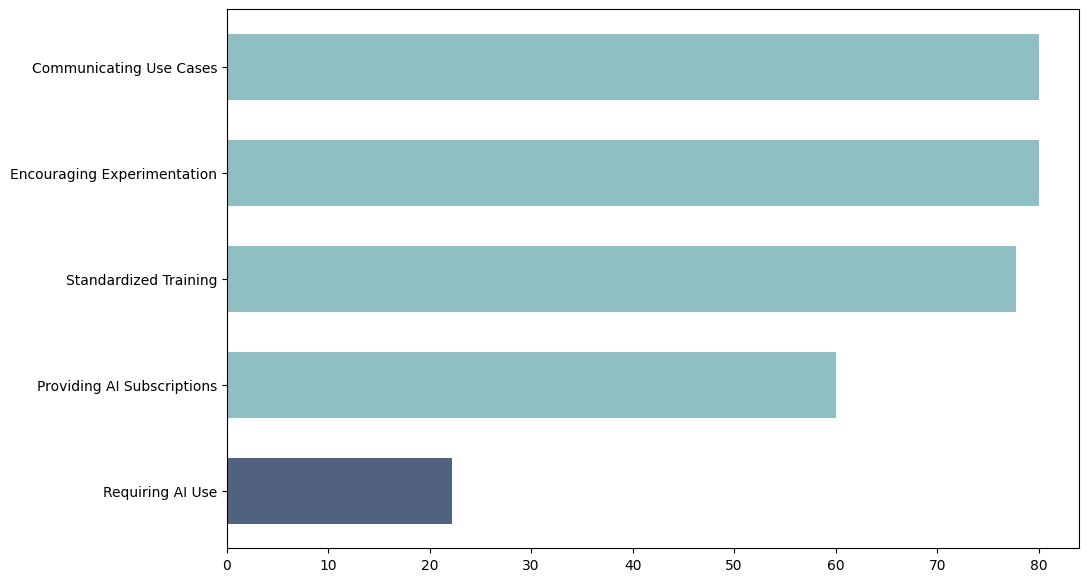

In [7]:
#Creating figure
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

bars = ax.barh(
    q5_df["response_option"],
    q5_df["percent"],
    color=q5_colors,
    height=0.62
)

In [8]:
#Adding percentage labels to bars
for bar, pct in zip(bars, q5_df["percent"]):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%",
        va="center",
        ha="left",
        fontsize=11,
        color=text_dark
    )

In [9]:
#Title and subtitle
ax.set_title(
    "Companies are encouraging AI experimentation,\nbut rarely requiring it",
    loc="left",
    fontsize=22,
    fontweight="bold",
    color=title_teal,
    pad=24
)

#Subtitle
ax.text(
    0,
    1,
    "Percentage of Organizations Promoting AI Adoption by Method (n = 45)",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    color=subtle_gray
)

#Callout box highlighting a key point of interest
ax.text(
    37,
    0.1,
    "Most organizations are encouraging AI adoption\nthrough communication, experimentation,\nand training, not mandates.",
    va="center",
    ha="left",
    fontsize=11,
    color=text_dark,
    bbox=dict(boxstyle="round,pad=0.45", facecolor=callout_bg, edgecolor="none")
)

Text(37, 0.1, 'Most organizations are encouraging AI adoption\nthrough communication, experimentation,\nand training, not mandates.')

In [10]:
# Formatting axes
ax.set_xlim(0, 100)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=11, colors=text_dark, length=0)
ax.tick_params(axis="x", labelsize=10, colors=subtle_gray)

#Editing the grid in the background
ax.xaxis.grid(True, color=grid_color, linewidth=1)
ax.set_axisbelow(True)

#Removing line around the chart for styling
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

In [11]:
#Note at the bottom for context and referencing
fig.text(
    0.01,
    0.01,
    "Research Survey, March 2026",
    fontsize=9,
    color=subtle_gray
)

Text(0.01, 0.01, 'Research Survey, March 2026')

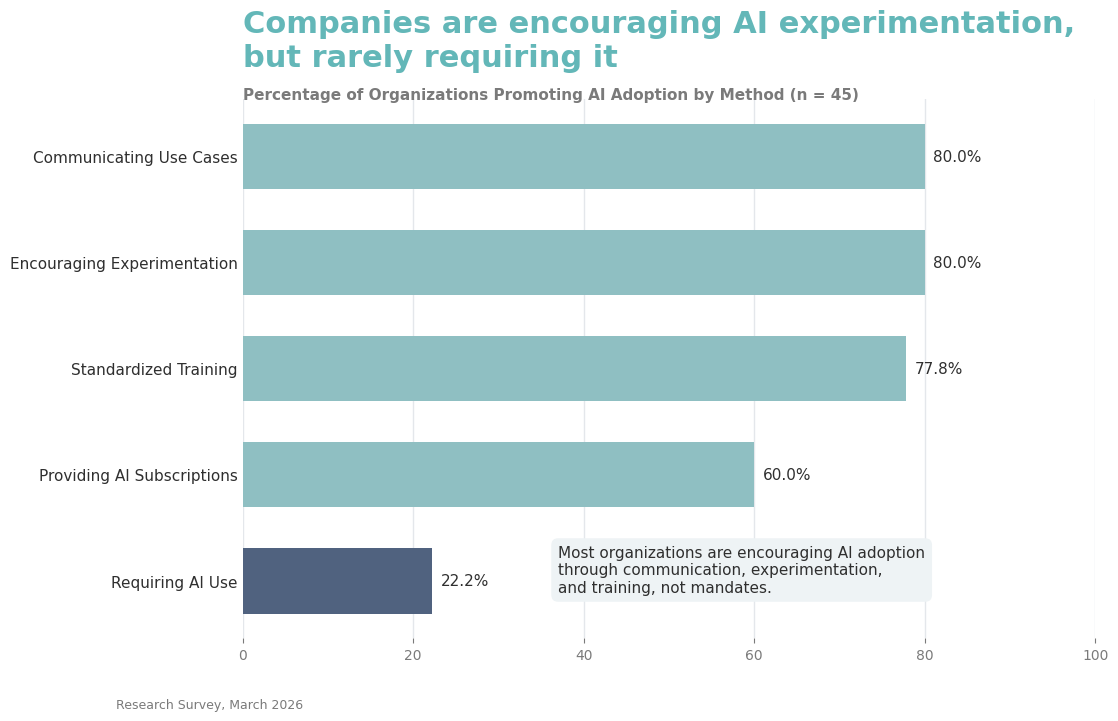

<Figure size 640x480 with 0 Axes>

In [12]:
#Generating the chart using display
from IPython.display import display

plt.tight_layout()
display(fig)
plt.close(fig)

#Visualization 2: *What* AI tools or platforms being used most?

In [13]:
#Filter to Question 7
q7_df = df[(df["question"] == "Q7") & (df["question_type"] == "multi_select")].copy()

#Sort by ascending percentage
q7_df = q7_df.sort_values("percent", ascending=True)

In [14]:
#Highlight the top category
bar_colors = [bar_blue] * len(q7_df)
bar_colors[-1] = bar_teal

In [15]:
#Shortening labels to be more user friendly
label_map = {
    "Generative AI for text (e.g., ChatGPT, Claude, Gemini, Copilot)": "Text Generation",
    "AI for productivity and collaboration (e.g., Microsoft Copilot, Google Duet, Notion AI)": "Productivity Tools",
    "AI for data analysis and business intelligence (e.g., Tableau AI, Power BI with AI, SAS Viya)": "Data Analysis/BI",
    "Proprietary in-house AI tools": "In-House AI Tools",
    "AI for coding and software development (e.g., GitHub Copilot, Amazon CodeWhisperer, Tabnine)": "Coding & Development",
    "AI for HR and recruiting (e.g., HireVue, Eightfold, Pymetrics)": "HR & Recruiting",
    "AI for marketing and customer engagement (e.g., Jasper, Persado, Drift, HubSpot AI)": "Marketing & Customer Engagement",
    "Generative AI for images/video (e.g., Midjourney, DALL¬∑E, Runway, Synthesia)": "Image/Video Generation"
}
#Replacing the responses with my label categories
q7_df["response_option"] = q7_df["response_option"].replace(label_map)



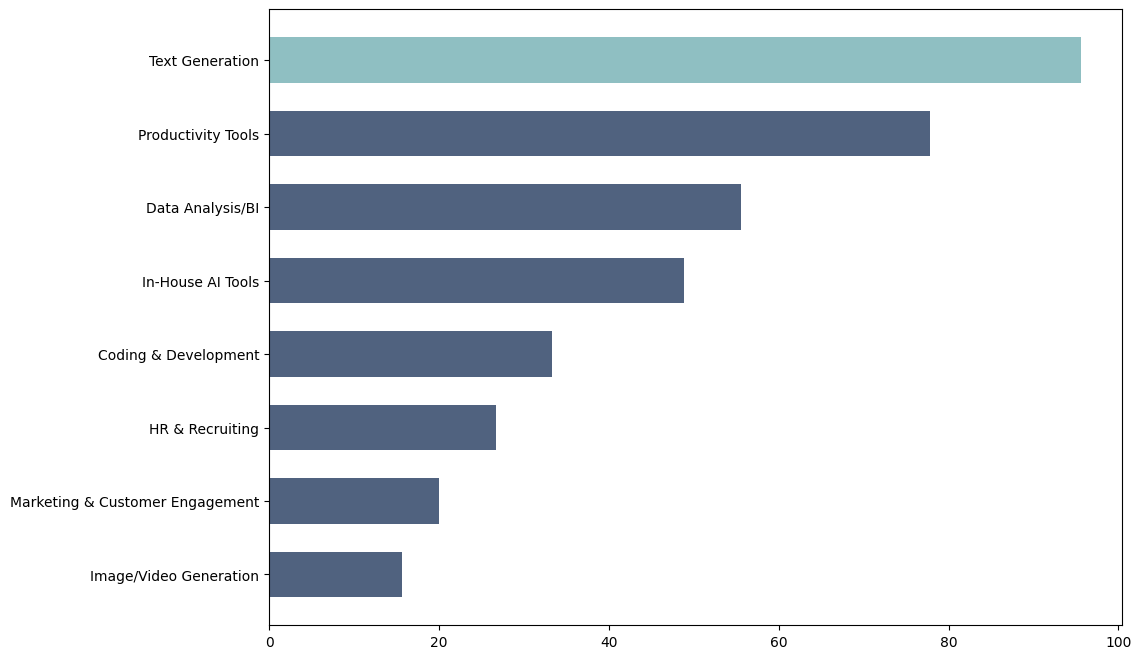

In [16]:
#Creating the figure
fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

bars = ax.barh(
    q7_df["response_option"],
    q7_df["percent"],
    color=bar_colors,
    height=0.62
)

In [17]:
#Adding percentage labels to the end of each bar
for bar, pct in zip(bars, q7_df["percent"]):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%",
        va="center",
        ha="left",
        fontsize=11,
        color=text_dark
    )

In [18]:
#Adding a title, subtitle, and small comment on the top percentage
ax.set_title(
    "Text generation dominates AI use at major enterprises",
    loc="left",
    fontsize=22,
    fontweight="bold",
    color=title_teal,
    pad=24
)

#Subtitle
ax.text(
    0,
    1,
    "Percentage of Organizations using each AI Tool Category (n=45)",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    color=subtle_gray
)

top_bar = bars[-1]
top_pct = q7_df["percent"].iloc[-1]

#Adding a small comment to highlight the top percentage (Text Generation)
ax.text(
    top_pct + 12,
    top_bar.get_y() + top_bar.get_height() / 2,
    "Nearly all respondents are \nadopting platforms like ChatGPT, \nClaude, Gemini, or Copilot for \ntext generation.",
    va="center",
    ha="left",
    fontsize=11,
    color=text_dark,
    #Creating the shape
    bbox=dict(boxstyle="round,pad=0.4", facecolor=callout_bg, edgecolor="none")
)

Text(107.6, 7.0, 'Nearly all respondents are \nadopting platforms like ChatGPT, \nClaude, Gemini, or Copilot for \ntext generation.')

In [19]:
#Clean formatting and labels for x axis, y axis
ax.set_xlim(0, 120)
ax.set_xlabel("")
ax.set_ylabel("")

#Styling the labels
ax.tick_params(axis="y", labelsize=11, colors=text_dark, length=0)
ax.tick_params(axis="x", labelsize=10, colors=subtle_gray)

#Styling the grid background/lines
ax.xaxis.grid(True, color=grid_color, linewidth=1)
ax.set_axisbelow(True)

#Removing the lines surrounding the bar chart for better visibility of callout box
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)


In [20]:
#Small reference text at the bottom
fig.text(
    0.01,
    0.01,
    "Research Survey, March 2026",
    fontsize=9,
    color=subtle_gray
)

Text(0.01, 0.01, 'Research Survey, March 2026')

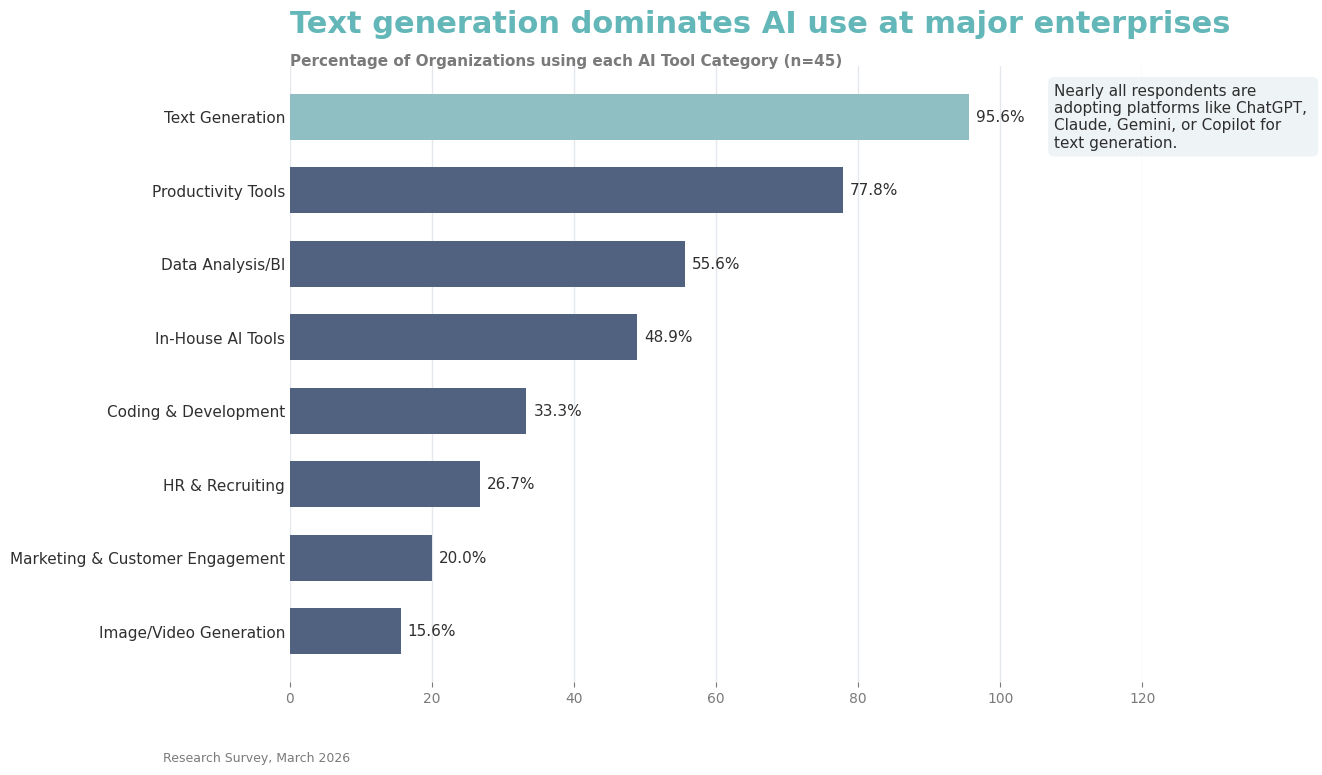

<Figure size 640x480 with 0 Axes>

In [21]:
#Displaying the chart!

from IPython.display import display

plt.tight_layout()
display(fig)
plt.close(fig)

# Visualization 3: What AI-related risks are companies worried about?

In [22]:
#Filtering to Question 10
q10_df = df[(df["question"] == "Q10") & (df["question_type"] == "multi_select")].copy()
#Removing zero responses
q10_df = q10_df[q10_df["count_n"] > 0].copy()
#Sort by ascending
q10_df = q10_df.sort_values("percent", ascending=True)

In [23]:
#Shortening labels
q10_label_map = {
    "Data security and/or privacy issues": "Data Security/Privacy",
    "Data accuracy issues": "Data Accuracy",
    "Spread of misinformation": "Misinformation",
    "Employee fears of job loss and/or replacement": "Job Displacement",
    "Deepfakes of CEO/corporate executives": "Deepfakes",
    "Negative economic outcomes (e.g. AI bubble, market downturn due to poor earnings, etc.) ": "Economic Impact",
    "Activist pressure against AI usage": "Activist Pressure",
    "Other (please specify)": "Other"
}
q10_df["response_option"] = q10_df["response_option"].replace(q10_label_map)

#Formatting: forcing "Other" to appear after "Activist Pressure" even though it has a higher percentage
other_row = q10_df[q10_df["response_option"] == "Other"]
q10_df = q10_df[q10_df["response_option"] != "Other"]

q10_df = pd.concat([other_row, q10_df], ignore_index=True)

In [24]:
#Highlight the top concern
q10_colors = [bar_blue] * len(q10_df)
q10_colors[-1] = bar_teal

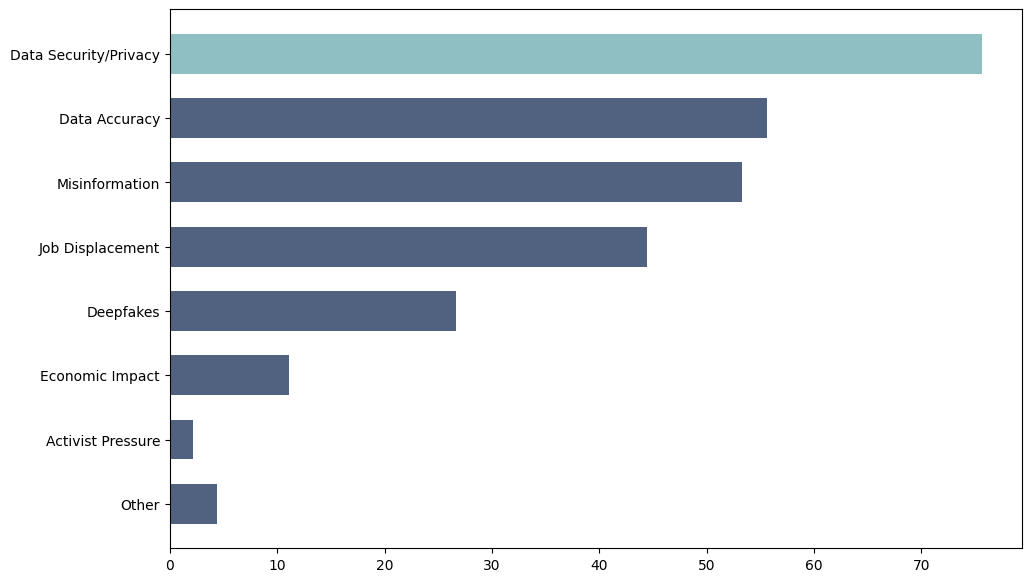

In [25]:
#Create chart!
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

bars = ax.barh(
    q10_df["response_option"],
    q10_df["percent"],
    color=q10_colors,
    height=0.62
)

In [26]:
#Percentage labels
for bar, pct in zip(bars, q10_df["percent"]):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%",
        va="center",
        ha="left",
        fontsize=11,
        color=text_dark
    )

In [27]:
#Title
ax.set_title(
    "Leaders cite data security and privacy as top AI concern",
    loc="left",
    fontsize=22,
    fontweight="bold",
    color=title_teal,
    pad=24
)

#Subtitle
ax.text(
    0,
    1,
    "Percentage of Organizations by Cited AI-Related Risk (n=45)",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    color=subtle_gray
)

#Callout
top_bar = bars[-1]
top_pct = q10_df["percent"].iloc[-1]

ax.text(
    top_pct - 6,
    top_bar.get_y() - 0.8,
    "Nearly 3 in 4 respondents cited\n"
"data security and privacy as their\n"
"top concern associated with AI adoption.",
    va="center",
    ha="left",
    fontsize=11,
    color=text_dark,
    bbox=dict(boxstyle="round,pad=0.45", facecolor=callout_bg, edgecolor="none")
)

Text(69.6, 5.890000000000001, 'Nearly 3 in 4 respondents cited\ndata security and privacy as their\ntop concern associated with AI adoption.')

In [28]:
#Axis formatting
ax.set_xlim(0, 100)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=11, colors=text_dark, length=0)
ax.tick_params(axis="x", labelsize=10, colors=subtle_gray)
ax.xaxis.grid(True, color=grid_color, linewidth=1)
ax.set_axisbelow(True)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

In [29]:
#Source note at the bottom
fig.text(
    0.01,
    0.01,
    "Research Survey, March 2026",
    fontsize=9,
    color=subtle_gray
)

Text(0.01, 0.01, 'Research Survey, March 2026')

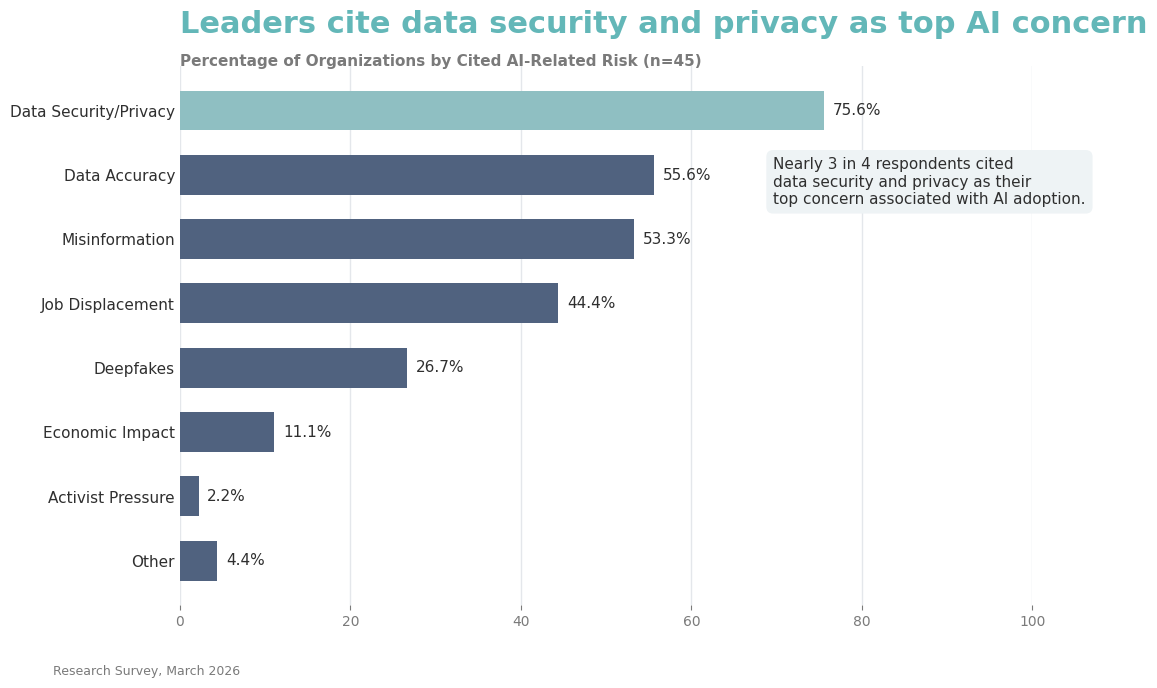

<Figure size 640x480 with 0 Axes>

In [30]:
from IPython.display import display

plt.tight_layout()
display(fig)

plt.close(fig)